In [1]:
from google.colab import files
uploaded = files.upload()

import os
print ("các tệp đã có")
print("Co gia_nha.csv chua?", os.path.exists("gia_nha.csv"))

Saving gia_nha.csv to gia_nha.csv
các tệp đã có
Co gia_nha.csv chua? True


In [2]:
import pandas as pd
df = pd.read_csv("gia_nha.csv")
print(df.shape, "| o thieu:", df.isna().sum().sum())
display(df.head(), df[["dien_tich", "gia"]].describe().round(2))

(60, 4) | o thieu: 0


,dien_tich,so_phong,tuoi_nha,gia
0,35.5,1,18,3.00
1,37.6,2,7,3.87
2,49.4,2,20,4.25
3,49.0,2,16,4.60
4,49.9,1,12,3.99


,dien_tich,gia
count,60.00,60.00
mean,77.73,6.49
std,20.22,1.64
min,35.50,3.00
25%,63.02,5.16
50%,75.10,6.40
75%,91.88,7.70
max,117.50,9.74


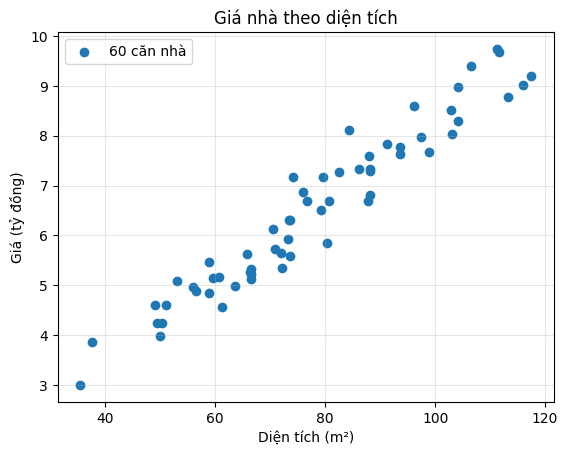

In [3]:
#Biểu đồ phân tán
import matplotlib.pyplot as plt
plt.scatter(df["dien_tich"], df["gia"], label="60 căn nhà")
plt.xlabel("Diện tích (m²)"); plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo diện tích"); plt.legend(); plt.grid(alpha=.3)
plt.show()

In [4]:
nho = df.iloc[[0, 14, 29, 44, 59]]
x, y = nho["dien_tich"].to_numpy(), nho["gia"].to_numpy()
mse = lambda w, b: ((y - (w * x + b)) ** 2).mean()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"y = {w}x + {b}")
    for xi, yi in zip(x, y):
        print(f"  {xi:6.1f} that={yi:5.2f} doan={w*xi+b:5.2f} sai so={yi-(w*xi+b):+6.2f}")
    print(f"  MSE = {mse(w, b):.4f}\n")

y = 0.05x + 1.5
    35.5 that= 3.00 doan= 3.28 sai so= -0.28
    61.3 that= 4.56 doan= 4.56 sai so= -0.00
    74.2 that= 7.17 doan= 5.21 sai so= +1.96
    91.3 that= 7.83 doan= 6.07 sai so= +1.76
   115.9 that= 9.01 doan= 7.30 sai so= +1.71
  MSE = 1.9947

y = 0.08x + 0.5
    35.5 that= 3.00 doan= 3.34 sai so= -0.34
    61.3 that= 4.56 doan= 5.40 sai so= -0.84
    74.2 that= 7.17 doan= 6.44 sai so= +0.73
    91.3 that= 7.83 doan= 7.80 sai so= +0.03
   115.9 that= 9.01 doan= 9.77 sai so= -0.76
  MSE = 0.3896



In [5]:
x, y = df["dien_tich"].to_numpy(), df["gia"].to_numpy()
w = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
b = y.mean() - w * x.mean()
print(f"w = {w:.6f} | b = {b:.6f}")
print(f"MSE tren 60 can = {((y - (w*x+b))**2).mean():.4f}")
print(f"Can 80 m2 -> {w*80+b:.3f} ty")

w = 0.078367 | b = 0.401752
MSE tren 60 can = 0.1790
Can 80 m2 -> 6.671 ty


In [6]:
from sklearn.linear_model import LinearRegression
X, y = df[["dien_tich"]], df["gia"]        # X hai ngoac vuong, y mot ngoac

mo_hinh = LinearRegression().fit(X, y)
print(f"w = {mo_hinh.coef_[0]:.6f} | b = {mo_hinh.intercept_:.6f}")
print(mo_hinh.predict(pd.DataFrame({"dien_tich": [80.0, 100.0]})).round(3))

w = 0.078367 | b = 0.401752
[6.671 8.238]


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
m = LinearRegression().fit(X_train, y_train)     # chỉ học trên 1 tập
y_pred = m.predict(X_test)                       # Xác minh trên valid

mse = mean_squared_error(y_test, y_pred)
print(f"Hoc {len(X_train)} can, kiem tra {len(X_test)} can")
print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f} ty")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {np.sqrt(mse):.4f} ty")
print(f"R2   = {r2_score(y_test, y_pred):.4f}")

Hoc 48 can, kiem tra 12 can
MAE  = 0.2578 ty
MSE  = 0.1392
RMSE = 0.3730 ty
R2   = 0.9622


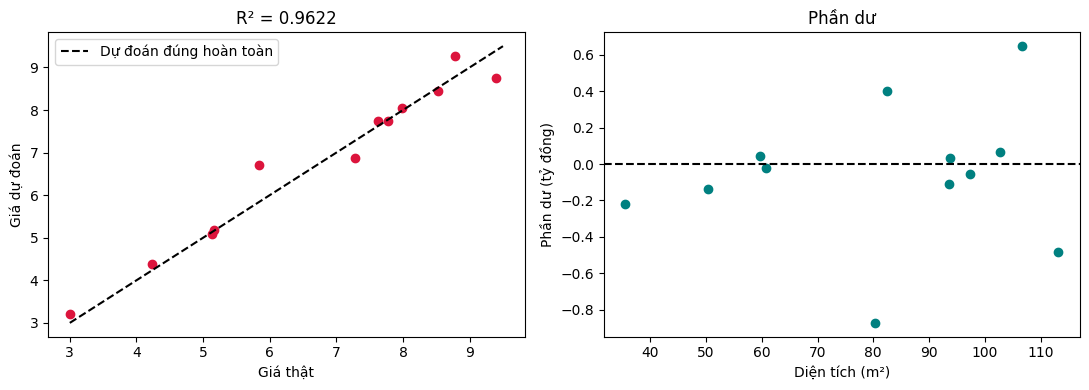

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(y_test, y_pred, c="crimson")
ax[0].plot([3, 9.5], [3, 9.5], "k--", label="Dự đoán đúng hoàn toàn")
ax[0].set_xlabel("Giá thật"); ax[0].set_ylabel("Giá dự đoán")
ax[0].set_title("R² = 0.9622"); ax[0].legend()

ax[1].scatter(X_test["dien_tich"], y_test - y_pred, c="teal")
ax[1].axhline(0, ls="--", c="k")
ax[1].set_xlabel("Diện tích (m²)"); ax[1].set_ylabel("Phần dư (tỷ đồng)")
ax[1].set_title("Phần dư")

plt.tight_layout(); plt.show()

# Gradient Descent

In [11]:
x_goc = df["dien_tich"].to_numpy(); y = df["gia"].to_numpy()
x_tb, x_sd = x_goc.mean(), x_goc.std()
x = (x_goc - x_tb) / x_sd
w = b = 0.0; lr = 0.1; n = len(x); lich_su = []
for vong in range(1, 201):
    chenh_lech = (w * x + b) - y
    w -= lr * (2/n) * (chenh_lech * x).sum()
    b -= lr * (2/n) * chenh_lech.sum()
    lich_su.append((((w*x+b) - y)**2).mean())
    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        print(f"{vong:4d}  w={w:7.4f}  b={b:7.4f}  MSE={lich_su[-1]:8.4f}")

print(f"\nĐổi về mét vuông w = {w/x_sd:.6f}, b = {b - w*x_tb/x_sd:.6f}")
print("Công thức w = 0.078367, b = 0.401752")

   1  w= 0.3143  b= 1.2987  MSE= 28.7437
   2  w= 0.5657  b= 2.3376  MSE= 18.4604
   5  w= 1.0564  b= 4.3656  MSE=  4.9714
  10  w= 1.4025  b= 5.7961  MSE=  0.6936
  25  w= 1.5653  b= 6.4688  MSE=  0.1797
  50  w= 1.5712  b= 6.4932  MSE=  0.1790
 100  w= 1.5713  b= 6.4933  MSE=  0.1790
 200  w= 1.5713  b= 6.4933  MSE=  0.1790

Đổi về mét vuông w = 0.078367, b = 0.401752
Công thức w = 0.078367, b = 0.401752


lr = 0.001  MSE sau 60 vòng = 35.2795
lr = 0.1    MSE sau 60 vòng = 0.1790
lr = 1.02   MSE sau 60 vòng = 4939.2961


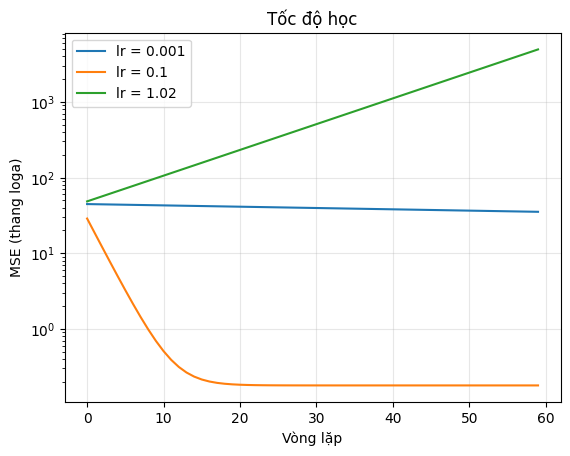

In [12]:
# Tương quan tốc độ học
def chay(lr, so_vong=60):
    w = b = 0.0; out = []
    for _ in range(so_vong):
        cl = (w * x + b) - y
        w -= lr * (2/n) * (cl * x).sum()
        b -= lr * (2/n) * cl.sum()
        out.append((((w*x+b) - y)**2).mean())
    return out

for lr in [0.001, 0.1, 1.02]:
    ket_qua = chay(lr)
    plt.plot(ket_qua, label=f"lr = {lr}")
    print(f"lr = {lr:<6} MSE sau 60 vòng = {ket_qua[-1]:.4f}")

plt.yscale("log"); plt.xlabel("Vòng lặp"); plt.ylabel("MSE (thang loga)")
plt.title("Tốc độ học"); plt.legend(); plt.grid(alpha=.3); plt.show()

In [13]:
# Thêm các biến số phòng và tuổi nhà
X3 = df[["dien_tich", "so_phong", "tuoi_nha"]]     # chi doi dung cho nay

for ten, Xi in [("Mot bien", X), ("Ba bien ", X3)]:
    a, b_, c, d = train_test_split(Xi, y, test_size=0.2, random_state=42)
    mi = LinearRegression().fit(a, c)
    print(f"{ten}: R2 = {r2_score(d, mi.predict(b_)):.4f}")

a, b_, c, d = train_test_split(X3, y, test_size=0.2, random_state=42)
m3 = LinearRegression().fit(a, c)
print("\nHe so:", dict(zip(X3.columns, m3.coef_.round(4))), "| chan:", round(m3.intercept_, 4))

Mot bien: R2 = 0.9622
Ba bien : R2 = 0.9761

He so: {'dien_tich': np.float64(0.0701), 'so_phong': np.float64(0.3042), 'tuoi_nha': np.float64(-0.0295)} | chan: 0.6917


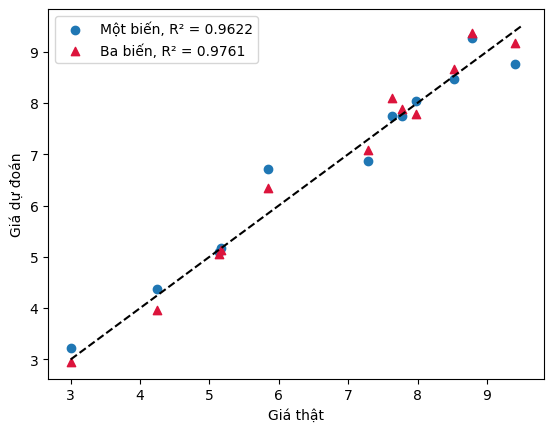

In [14]:
plt.scatter(d, m.predict(b_[["dien_tich"]]), label="Một biến, R² = 0.9622")
plt.scatter(d, m3.predict(b_), marker="^", c="crimson", label="Ba biến, R² = 0.9761")
plt.plot([3, 9.5], [3, 9.5], "k--")
plt.xlabel("Giá thật"); plt.ylabel("Giá dự đoán"); plt.legend(); plt.show()

## Bài tập 1: Lọc ra nhóm căn hộ lớn
Đếm số căn có diện tích > 100 m² và tính giá trung bình của riêng nhóm đó.

In [16]:
# Lọc nhóm căn hộ lớn
nhom_lon = df[df["dien_tich"] > 100]
print(f"Số Căn > 100 m2      : {len(nhom_lon)}")
print(f"Giá trung bình nhóm : {nhom_lon['gia'].mean():.4f} ty dong")
print(f"Giá trung bình 60 căn: {df['gia'].mean():.4f} ty dong")
print("\nNhan xet: nhom can lon chi chiem 10/60 can nhung gia trung binh"
      " cao hon han mat bang chung, dung voi xu huong di len o Hinh 1.")

Số Căn > 100 m2      : 10
Giá trung bình nhóm : 8.9620 ty dong
Giá trung bình 60 căn: 6.4933 ty dong

Nhan xet: nhom can lon chi chiem 10/60 can nhung gia trung binh cao hon han mat bang chung, dung voi xu huong di len o Hinh 1.


## Bài tập 2: Vẽ biểu đồ phân tán theo số phòng


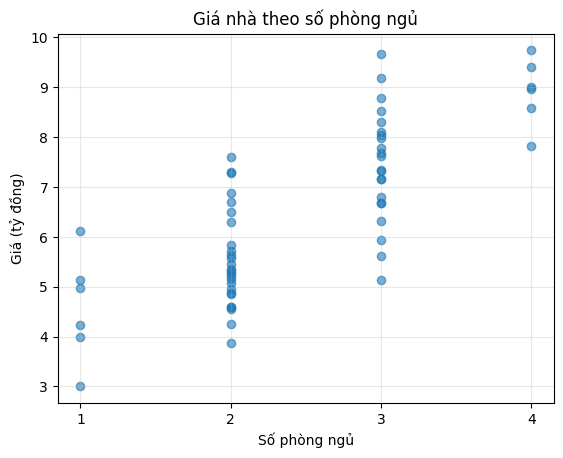

          count  mean
so_phong             
1             6  4.58
2            26  5.57
3            22  7.45
4             6  8.92

Nhan xet: gia tang dan theo so phong, nhung cac diem xep thanh bon cot doc chu khong trai deu nhu bieu do dien tich.


In [17]:
# scatter theo số phòng
plt.scatter(df["so_phong"], df["gia"], alpha=.6)
plt.xlabel("Số phòng ngủ"); plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo số phòng ngủ")
plt.xticks([1, 2, 3, 4]); plt.grid(alpha=.3)
plt.savefig("bai2.png", dpi=150)     # luu TRUOC khi show
plt.show()

print(df.groupby("so_phong")["gia"].agg(["count", "mean"]).round(2))
print("\nNhan xet: gia tang dan theo so phong, nhung cac diem xep thanh"
      " bon cot doc chu khong trai deu nhu bieu do dien tich.")

## Bài tập 3: Đổi biến đầu vào sang tuổi nhà
Dùng lại công thức bình phương tối thiểu, nhưng x là `tuoi_nha` thay vì `dien_tich`.

w = -0.037858
b = 6.983593


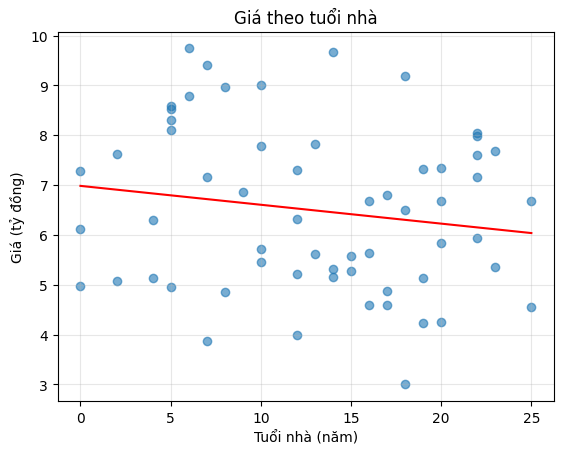

Nhan xet: w am nghia la nha cang cu gia cang thap, dung voi truc giac. Nhung cac diem tan rat rong quanh duong thang, khac han bieu do dien tich.


In [18]:
# Hồi quy giá theo tuổi nhà
xt, yt = df["tuoi_nha"].to_numpy(), df["gia"].to_numpy()
w3 = ((xt - xt.mean()) * (yt - yt.mean())).sum() / ((xt - xt.mean()) ** 2).sum()
b3 = yt.mean() - w3 * xt.mean()
print(f"w = {w3:.6f}\nb = {b3:.6f}")

plt.scatter(xt, yt, alpha=.6)
plt.plot([0, 25], [w3*0 + b3, w3*25 + b3], "r")
plt.xlabel("Tuổi nhà (năm)"); plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá theo tuổi nhà"); plt.grid(alpha=.3); plt.show()

print("Nhan xet: w am nghia la nha cang cu gia cang thap, dung voi truc giac."
      " Nhung cac diem tan rat rong quanh duong thang, khac han bieu do dien tich.")

## Bài tập 4: Thêm số phòng vào mô hình
Hai biến `dien_tich` + `so_phong`, so R² với mô hình một biến (0.9622).

In [19]:
# Mô Hình Hai biến
X2 = df[["dien_tich", "so_phong"]]
a2, b2, c2, d2 = train_test_split(X2, y, test_size=0.2, random_state=42)
m2 = LinearRegression().fit(a2, c2)
r2_hai = r2_score(d2, m2.predict(b2))

print(f"Mot bien  (dien_tich)            : R2 = 0.9622")
print(f"Hai bien  (dien_tich + so_phong) : R2 = {r2_hai:.4f}")
print("Ba bien   (them tuoi_nha)        : R2 = 0.9761")
print("\nHe so:", dict(zip(X2.columns, m2.coef_.round(4))), "| chan:", round(m2.intercept_, 4))
print("\nNhan xet: them so_phong lam R2 tang, nhung muc tang nho vi dien_tich"
      " da giai thich gan het bien dong gia.")

Mot bien  (dien_tich)            : R2 = 0.9622
Hai bien  (dien_tich + so_phong) : R2 = 0.9698
Ba bien   (them tuoi_nha)        : R2 = 0.9761

He so: {'dien_tich': np.float64(0.0702), 'so_phong': np.float64(0.2704)} | chan: 0.3667

Nhan xet: them so_phong lam R2 tang, nhung muc tang nho vi dien_tich da giai thich gan het bien dong gia.


## Bài tập 5: Thử hai tốc độ học khác
Chạy lại gradient descent 200 vòng với lr = 0.001 và lr = 1.02, giữ nguyên mọi thứ khác.

In [20]:
# Tương quan các mức độ learning rate
for lr in [0.001, 0.1, 1.02]:
    mse_cuoi = chay(lr, so_vong=200)[-1]
    print(f"lr = {lr:<6} MSE sau 200 vong = {mse_cuoi:.4f}")

print("\nNhan xet: lr = 0.001 buoc qua ngan nen 200 vong van chua toi day."
      " lr = 0.1 ve dung 0.1790. lr = 1.02 buoc qua dai nen nhay qua day,"
      " sai so tang theo cap so nhan va phinh ra con so vo nghia.")

lr = 0.001  MSE sau 200 vong = 20.2175
lr = 0.1    MSE sau 200 vong = 0.1790
lr = 1.02   MSE sau 200 vong = 290391782.0192

Nhan xet: lr = 0.001 buoc qua ngan nen 200 vong van chua toi day. lr = 0.1 ve dung 0.1790. lr = 1.02 buoc qua dai nen nhay qua day, sai so tang theo cap so nhan va phinh ra con so vo nghia.


## Bài tập 6: Hàm dự đoán có cảnh báo ngoại suy
Hàm `du_doan_gia(dien_tich)` trả về giá dự đoán, kèm cảnh báo nếu ra ngoài khoảng 35.5 – 117.5 m².

In [22]:
# Hàm dự đoán
W, B = 0.078367, 0.401752      # hai he so tu Cell 5
MIN_DT, MAX_DT = 35.5, 117.5   # khoang dien tich co trong du lieu

def du_doan_gia(dien_tich):
    """Du doan gia can ho tu dien tich, canh bao neu ngoai vung du lieu."""
    if dien_tich < MIN_DT or dien_tich > MAX_DT:
        print(f"  CANH BAO: {dien_tich} m2 nam ngoai khoang {MIN_DT}-{MAX_DT} m2,"
              " mo hinh chua tung thay vung nay nen con so chi la suy doan keo dai.")
    return W * dien_tich + B

for dt in [60, 80, 200]:
    print(f"Can {dt} m2 -> {du_doan_gia(dt):.3f} ty dong\n")

Can 60 m2 -> 5.104 ty dong

Can 80 m2 -> 6.671 ty dong

  CANH BAO: 200 m2 nam ngoai khoang 35.5-117.5 m2, mo hinh chua tung thay vung nay nen con so chi la suy doan keo dai.
Can 200 m2 -> 16.075 ty dong

